# Sprint 9 — Tomando Decisões de Negócios Baseados em Dados
### por Luiz Trajano

## Contexto

Nesse projeto serei um analista em uma **grande loja online**. Junto com o departamento de marketing, compilei uma
lista de hipóteses que podem ajudar a aumentar a receita. Neste projeto eu vou:

1. **Priorizar** essas hipóteses (frameworks **ICE** e **RICE**);
2. Analisar os resultados de um **teste A/B** já realizado;
3. Tomar uma **decisão de negócio** baseada nos dados.

## Descrição dos dados

**Parte 1 — `Data/hypotheses_us.csv`** (separador `;`)
- `Hypothesis` — descrição da hipótese
- `Reach` — alcance (1 a 10)
- `Impact` — impacto (1 a 10)
- `Confidence` — confiança (1 a 10)
- `Effort` — esforço/recursos (1 a 10; quanto maior, mais recursos)

**Parte 2 — `Data/orders_us.csv`**
- `transactionId` — id do pedido · `visitorId` — id do usuário · `date` — data
- `revenue` — valor do pedido · `group` — grupo do teste A/B (A ou B)

**Parte 2 — `Data/visits_us.csv`**
- `date` — data · `group` — grupo A/B · `visits` — nº de visitas na data/grupo

## 0. Preparação dos dados

Começo importando as bibliotecas e carregando os três datasets, cada um com o separador correto.

In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Ajustes de exibição
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)

# Carregar os datasets
hypotheses = pd.read_csv('Data/hypotheses_us.csv', sep=';')
orders     = pd.read_csv('Data/orders_us.csv', parse_dates=['date'])
visits     = pd.read_csv('Data/visits_us.csv', parse_dates=['date'])

orders_raw = orders.copy()

# Visão inicial
print('hypotheses:', hypotheses.shape, '| orders:', orders.shape, '| visits:', visits.shape)
display(hypotheses)
print('Orders:')
display(orders.head(10))
print('Visits:')
display(visits.head(10))

hypotheses: (9, 5) | orders: (1197, 5) | visits: (62, 3)


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


Orders:


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B
6,398296753,2900797465,2019-08-15,30.6,B
7,2626614568,78758296,2019-08-15,20.1,A
8,1576988021,295230930,2019-08-15,215.9,A
9,1506739906,1882260405,2019-08-15,30.5,B


Visits:


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


### 0.1 Pré-processamento

Antes de analisar, vou garantir que os dados estão limpos: confiro tipos e valores ausentes,
procuro duplicados e — ponto crítico do enunciado — verifico se algum visitante caiu nos grupos
**A e B** ao mesmo tempo, porque esses usuários contaminam o teste e eu preciso tratá-los.

In [2]:
# 1. Tipos e valores ausentes

orders.info()
visits.info()
print()
print(orders.isna().sum())
print(visits.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB

transactionId    0
visitorId        0
date             0
revenu

In [3]:
# 2. Duplicados
# print('duplicados orders:', orders.duplicated().sum())
# print('duplicados visits:', visits.duplicated().sum())

print('Duplicados orders:', orders.duplicated().sum())
print('Duplicados visits:', visits.duplicated().sum())

# Duplicados em transacionId:

print('transactionId repetido    :', orders['transactionId'].duplicated().sum())
print('visits date+group repetido:', visits.duplicated(subset=['date', 'group']).sum())

Duplicados orders: 0
Duplicados visits: 0
transactionId repetido    : 0
visits date+group repetido: 0


In [4]:
# 3. IMPORTANTE — visitantes que caíram em A E B ao mesmo tempo:
# Separar os que temos apenas em A e em B, depois ver se temos contaminados,
# ou seja, em ambos os grupos

usuarios_A = set(orders_raw[orders_raw['group'] == 'A']['visitorId'])
usuarios_B = set(orders_raw[orders_raw['group'] == 'B']['visitorId'])
contaminados = usuarios_A & usuarios_B

print('Contaminados, que aparecem em ambos os grupos: ', len(contaminados))

# 3.1 Qual o peso desses usuários?
visitantes = orders_raw['visitorId'].nunique()
ped_contam = orders_raw['visitorId'].isin(contaminados).sum()

print(f'\nVisitantes únicos : {visitantes}')
print(f'Contaminados      : {len(contaminados)} ({len(contaminados)/visitantes:.1%} dos visitantes)')
print(f'Pedidos deles     : {ped_contam} ({ped_contam/len(orders_raw):.1%} dos pedidos)')

print('\nComo os pedidos contaminados se dividem entre os grupos:')
print(orders_raw[orders_raw['visitorId'].isin(contaminados)]['group'].value_counts().to_string())

Contaminados, que aparecem em ambos os grupos:  58

Visitantes únicos : 1031
Contaminados      : 58 (5.6% dos visitantes)
Pedidos deles     : 181 (15.1% dos pedidos)

Como os pedidos contaminados se dividem entre os grupos:
group
B    92
A    89


In [5]:
# 4. Remoção dos contaminados (filtro a partir de orders_raw -> célula reexecutável)
orders = orders_raw[~orders_raw['visitorId'].isin(contaminados)]

print(f'Pedidos: {len(orders_raw)} -> {len(orders)}')
print(pd.DataFrame({'antes':  orders_raw['group'].value_counts(),
                    'depois': orders['group'].value_counts()}).to_string())

print('\nAinda contaminados:', (orders.groupby('visitorId')['group'].nunique() > 1).sum())

print(f'\nPedidos por usuário | contaminados: {ped_contam/len(contaminados):.2f}'
    f' | demais: {len(orders)/orders["visitorId"].nunique():.2f}')

Pedidos: 1197 -> 1016
       antes  depois
group               
B        640     548
A        557     468

Ainda contaminados: 0

Pedidos por usuário | contaminados: 3.12 | demais: 1.04


In [6]:
# conferindo o intervalo de datas do teste, pode vir a ser útil

print(orders['date'].min(), '->', orders['date'].max())

2019-08-01 00:00:00 -> 2019-08-31 00:00:00


In [7]:
# 5. Sanidade dos valores e cobertura temporal
print('revenue | min:', orders['revenue'].min(),
    '| max:', orders['revenue'].max(),
    '| <= 0:', (orders['revenue'] <= 0).sum())

print('\nPeríodo:', orders['date'].min().date(), '->', orders['date'].max().date(),
    '|', orders['date'].dt.date.nunique(), 'dias')

print('Dias com dados por grupo em visits:')
print(visits.groupby('group')['date'].nunique().to_string())

revenue | min: 5.0 | max: 19920.4 | <= 0: 0

Período: 2019-08-01 -> 2019-08-31 | 31 dias
Dias com dados por grupo em visits:
group
A    31
B    31


**Observações do pré-processamento:** 

**Qualidade dos dados.** Os três arquivos vieram limpos: nenhum valor ausente, nenhuma linha
duplicada e nenhum `transactionId` repetido. Em `visits`, cada par data+grupo aparece uma única
vez. A coluna `date` já foi lida como `datetime` graças ao `parse_dates`, então não precisei
converter tipos. Os valores de `revenue` vão de 5,00 a 19.920,40, sem negativos nem zeros.

**Cobertura temporal.** O teste rodou de 01/08/2019 a 31/08/2019 — 31 dias corridos, sem dias
faltantes em nenhum dos grupos. Isso cobre mais de 4 ciclos semanais completos, o que ajuda a
diluir a sazonalidade de dia da semana. Como 31 não é múltiplo de 7, temos mais 3 dias extras, um leve desbalanceamento a registrar.

**Contaminação entre grupos.** Encontrei ___ visitantes presentes nos grupos A e B ao mesmo
tempo (5,6% dos 1031 visitantes únicos). Embora sejam poucos usuários, eles respondem por 181 pedidos — 15,1% do total. Decidi removê-los porque um usuário exposto às duas versões
não permite atribuir o pedido a um tratamento específico: mantê-lo violaria a independência
entre os grupos e o mesmo comportamento de compra entraria nas duas médias, empurrando A e B
artificialmente na direção um do outro e mascarando qualquer diferença real.
Após a remoção, os pedidos caíram de 1197 para 1016 e os grupos ficaram com A=468 e B=548,
mantendo o equilíbrio (os pedidos removidos estavam quase igualmente divididos: 89 em A e 92 em B).

**Limitação conhecida.** O `visits_us.csv` está agregado por data e grupo, sem `visitorId`. Por
isso não consigo excluir das visitas os mesmos 58 usuários que removi dos pedidos: o numerador da conversão perde 181 pedidos, mas o denominador continua contando todas as sessões deles.
Consequência: a taxa de conversão fica subestimada nos dois grupos e deve ser lida como um piso, não como o valor real. Como a contaminação se distribuiu de forma quase simétrica entre A e B, a comparação entre os grupos permanece válida — é o nível absoluto que está deslocado.

---
# Parte 1 — Priorizando Hipóteses

Nesta primeira parte vou priorizar as **9 hipóteses** de aumento de receita do arquivo
`hypotheses_us.csv`. Cada uma tem `Reach`, `Impact`, `Confidence` e `Effort` — vou pontuá-las
primeiro com **ICE** e depois com **RICE**.

### 1.1 Framework ICE

$$ICE = \frac{Impact \times Confidence}{Effort}$$

Vou aplicar o framework **ICE**: crio a coluna `ICE` e ordeno as hipóteses em ordem
**decrescente** de prioridade.

In [8]:
# 1. Criando a coluna 'ICE'
# hypotheses['ICE'], vou exibir o texto da hipótese completo e o ICE
# Ordenando decrescente por ICE

hypotheses['ICE'] = hypotheses['Impact'] * hypotheses['Confidence'] / hypotheses['Effort']
pd.set_option('display.max_colwidth', None)
display(hypotheses[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False))

,Hypothesis,ICE
8,Launch a promotion that gives users discounts on their birthdays,16.200000
0,Add two new channels for attracting traffic. This will bring 30% more users,13.333333
7,Add a subscription form to all the main pages. This will help you compile a mailing list,11.200000
6,Show banners with current offers and sales on the main page. This will boost conversion,8.000000
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,7.000000
1,Launch your own delivery service. This will shorten delivery time,2.000000
5,Add a customer review page. This will increase the number of orders,1.333333
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,1.125000
4,Change the background color on the main page. This will increase user engagement,1.000000


### 1.2 Framework RICE

$$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

Agora vou aplicar o **RICE** (que também considera o alcance): crio a coluna `RICE` e ordeno em
ordem **decrescente**.

In [9]:
# 1. Criando a coluna 'RICE' (agora o Reach entra na conta)
# hypotheses['RICE']

hypotheses['RICE'] = hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence'] / hypotheses['Effort']
pd.set_option('display.max_colwidth', None)
display(hypotheses[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False))

# 2. Ordene decrescente por RICE e mostre
# display(hypotheses[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False))

,Hypothesis,RICE
7,Add a subscription form to all the main pages. This will help you compile a mailing list,112.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,56.0
0,Add two new channels for attracting traffic. This will bring 30% more users,40.0
6,Show banners with current offers and sales on the main page. This will boost conversion,40.0
8,Launch a promotion that gives users discounts on their birthdays,16.2
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,9.0
1,Launch your own delivery service. This will shorten delivery time,4.0
5,Add a customer review page. This will increase the number of orders,4.0
4,Change the background color on the main page. This will increase user engagement,3.0


### 1.3 Como a priorização muda (ICE × RICE)

Vou colocar as duas pontuações lado a lado para ver **quais hipóteses sobem ou descem** ao trocar
ICE por RICE — e explicar o porquê.

In [10]:
# 1. Mostrando a tabela com ICE e RICE lado a lado, ordenada por RICE
# display(hypotheses[['Hypothesis', 'ICE', 'RICE']].sort_values(by='RICE', ascending=False))

display(hypotheses[['Hypothesis', 'ICE', 'RICE']].sort_values(by='RICE', ascending=False))

# Comparar as posições. Lembrete: o Reach só entra no RICE
# hipóteses de alto alcance tendem a SUBIR quando você usa RICE.

hypotheses['position_ICE']  = hypotheses['ICE'].rank(ascending=False, method='min').astype(int)
hypotheses['position_RICE'] = hypotheses['RICE'].rank(ascending=False, method='min').astype(int)
display(
    hypotheses[['Hypothesis', 'position_ICE', 'position_RICE']]
    .sort_values('position_RICE'))

# Detalhe curioso na hipostese 8: ICE = RICE

display(hypotheses.loc[8])

,Hypothesis,ICE,RICE
7,Add a subscription form to all the main pages. This will help you compile a mailing list,11.200000,112.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,7.000000,56.0
0,Add two new channels for attracting traffic. This will bring 30% more users,13.333333,40.0
6,Show banners with current offers and sales on the main page. This will boost conversion,8.000000,40.0
8,Launch a promotion that gives users discounts on their birthdays,16.200000,16.2
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,1.125000,9.0
1,Launch your own delivery service. This will shorten delivery time,2.000000,4.0
5,Add a customer review page. This will increase the number of orders,1.333333,4.0
4,Change the background color on the main page. This will increase user engagement,1.000000,3.0


,Hypothesis,position_ICE,position_RICE
7,Add a subscription form to all the main pages. This will help you compile a mailing list,3,1
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,5,2
0,Add two new channels for attracting traffic. This will bring 30% more users,2,3
6,Show banners with current offers and sales on the main page. This will boost conversion,4,3
8,Launch a promotion that gives users discounts on their birthdays,1,5
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,8,6
1,Launch your own delivery service. This will shorten delivery time,6,7
5,Add a customer review page. This will increase the number of orders,7,7
4,Change the background color on the main page. This will increase user engagement,9,9


Hypothesis       Launch a promotion that gives users discounts on their birthdays
Reach                                                                           1
Impact                                                                          9
Confidence                                                                      9
Effort                                                                          5
ICE                                                                          16.2
RICE                                                                         16.2
position_ICE                                                                    1
position_RICE                                                                   5
Name: 8, dtype: object

**📝 Conclusão 1.3:** Ao trocar o ICE pelo RICE o ranking muda quase por completo, e a causa é uma só: o **Reach**, que
entra apenas no RICE. O ICE mede a qualidade da ideia por usuário impactado (impacto × confiança
÷ esforço), mas ignora *quantos* usuários ela alcança. O RICE corrige isso multiplicando pelo
alcance — por isso ele recompensa hipóteses que tocam muita gente e penaliza as que, por melhores
que sejam, atingem poucos.

**Casos de ICE baixo e RICE alto** (o alcance "resgata" a hipótese):
- *Blocos de recomendação* (idx 2): estava em **5º no ICE (7,0)** e sobe para **2º no RICE (56,0)**.
  Sozinho, seu impacto por usuário é modesto, mas com **Reach = 8** o ganho se multiplica por toda
  a base.
- *Formulário de inscrição* (idx 7): de **3º (ICE 11,2)** para **1º (RICE 112,0)**, puxado pelo
  maior alcance da lista (**Reach = 10**).

**Caso oposto — ICE alto e RICE baixo:**
- *Descontos de aniversário* (idx 8): **líder no ICE (16,2)**, despenca para **5º no RICE (16,2)**.
  Impacto e confiança altíssimos (9 e 9), mas **Reach = 1**: uma ótima ideia que quase ninguém vê.
  O ICE a superestima justamente por não enxergar o alcance.

**Qual eu usaria.** Para priorizar por retorno agregado — o objetivo aqui, aumentar a receita da
loja — o **RICE** é o mais indicado, porque incorpora quantos usuários cada mudança atinge. O ICE
seria preferível só quando o alcance é parecido entre as hipóteses ou irrelevante para a decisão.
Pelo RICE, minha prioridade nº 1 é o **formulário de inscrição (idx 7)**.

### Extra que notei: 

* A hipótese 8 é a única em que ICE e RICE são idênticos (16,2), porque seu Reach = 1. Como RICE = Reach × ICE, multiplicar por 1 não altera o valor — é o único caso em que o alcance "não faz diferença". Em todas as outras, o Reach (≥ 2) reescala o ICE para cima. Vale citar que o reach sempre puxa o RICE para cima ou se mantém nesse último caso, nunca para baixo. O que muda o ranking não é o valor absoluto subir, e sim quanto ele sobe em cada hipótese — quem tem Reach alto sobe muito e ultrapassa quem tem Reach baixo. O idx 8 fica pra trás não porque caiu, mas porque foi o que menos subiu (× 1) enquanto os outros multiplicaram por 8, 10, etc.

---
# Parte 2 — Análise do Teste A/B

Agora vou analisar o teste A/B. Em cada passo eu gero o gráfico ou o cálculo pedido, **interpreto
o que vejo** e **crio conjecturas**.

### 2.0 Dados acumulados (estrutura compartilhada)

Primeiro vou montar uma estrutura com os totais **acumulados** por data e grupo, que eu reaproveito
nos gráficos acumulados (2.1 a 2.5).

In [11]:
# Objetivo: para cada par (data, grupo), somar pedidos/receita/visitas ACUMULADOS até a data.

# 1. Pares únicos de data e grupo

datesGroups = orders[['date', 'group']].drop_duplicates()

# 2. para cada linha de datesGroups, filtrarei tudo que aconteceu até aquela data,
# naquele grupo, e agregar (somando receita, contando pedidos únicos, contando usuários únicos)

ordersAggregated = datesGroups.apply(
    lambda x: orders[
        np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])
    ].agg({
        'date': 'max',
        'group': 'max',
        'transactionId': pd.Series.nunique,
        'visitorId': pd.Series.nunique,
        'revenue': 'sum'
    }),
    axis=1
).sort_values(by=['date', 'group'])

# 3. mesmo processo, mas para a contagem cumulativa de visitantes

visitorsAggregated = datesGroups.apply(
    lambda x: visits[
        np.logical_and(visits['date'] <= x['date'], visits['group'] == x['group'])
    ].agg({
        'date': 'max',
        'group': 'max',
        'visits': 'sum'
    }),
    axis=1
).sort_values(by=['date', 'group'])

# 4. Junto tudo em 'cumulativeData' e renomeio as colunas para:
#    ['date','group','orders','buyers','revenue','visitors']
# com nomes de coluna descritivos
# Opto por display por ajuda na visualização, mas poderia ser print(cumulativeData.head(10))

cumulativeData = ordersAggregated.merge(
    visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']
display(cumulativeData.head(10))
print('\nTeste de data: ', cumulativeData[cumulativeData['date'] == '2019-08-31'])

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,2266.6,719
1,2019-08-01,B,17,17,967.2,713
2,2019-08-02,A,42,36,3734.9,1338
3,2019-08-02,B,40,39,3535.3,1294
4,2019-08-03,A,66,60,5550.1,1845
5,2019-08-03,B,54,53,4606.9,1803
6,2019-08-04,A,77,71,6225.6,2562
7,2019-08-04,B,68,66,6138.5,2573
8,2019-08-05,A,99,92,7623.6,3318
9,2019-08-05,B,89,87,7587.8,3280



Teste de data:           date group  orders  buyers  revenue  visitors
60 2019-08-31     A     468     445  53212.0     18736
61 2019-08-31     B     548     528  79651.2     18916


### 2.1 Receita acumulada por grupo

Vou traçar a **receita acumulada** de cada grupo ao longo do tempo e interpretar o que vejo.

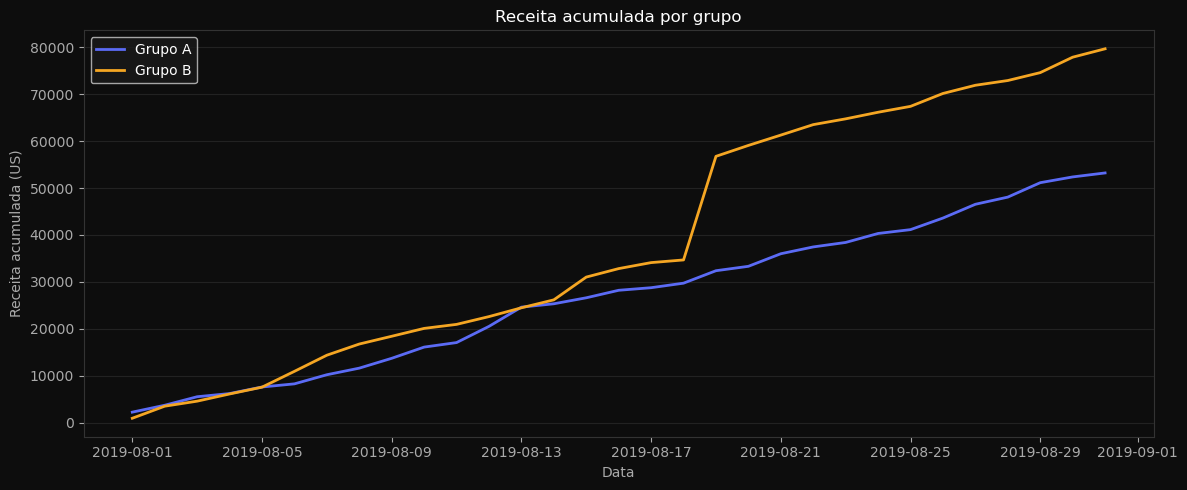

In [12]:
# Separo a receita acumulada de cada grupo

cumulativeRevenueA = cumulativeData[cumulativeData['group'] == 'A']
cumulativeRevenueB = cumulativeData[cumulativeData['group'] == 'B']

# Ploto a receita acumulada dos dois grupos ao longo do tempo

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'],
        color='#5B6BF5', linewidth=2, label='Grupo A')
ax.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'],
        color='#F5A623', linewidth=2, label='Grupo B')

ax.set_title('Receita acumulada por grupo', color='white')
ax.set_xlabel('Data', color='#aaaaaa')
ax.set_ylabel('Receita acumulada (US)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.yaxis.grid(True, color='#222222', zorder=0)
ax.set_axisbelow(True)
ax.legend(facecolor='#1a1a1a', labelcolor='white')

plt.tight_layout()
plt.show()


In [13]:
# Investigarei o degrau da curva de B: qual pedido causou o salto? 
# Questão necessária para entender o salto do dia 19/08

# 1. Isolo o maior pedido do grupo B
maior_B = orders[orders['group'] == 'B'].loc[orders[orders['group'] == 'B']['revenue'].idxmax()]
dia_salto = maior_B['date']

# 2. Receita diária do B em torno do salto (18 a 20/08)
receita_dia_B = orders[orders['group'] == 'B'].groupby('date')['revenue'].sum()
print('Receita diária do B (18 a 20/08):')
print(receita_dia_B.loc['2019-08-18':'2019-08-20'].round(1).to_string())

# 3. Peso do outlier
receita_dia = orders[(orders['date'] == dia_salto) & (orders['group'] == 'B')]['revenue'].sum()
receita_mes_B = orders[orders['group'] == 'B']['revenue'].sum()
print(f'\nMaior pedido do B: US$ {maior_B["revenue"]:.2f} '
      f'(visitorId {maior_B["visitorId"]}) em {dia_salto.date()}')
print(f'  → {maior_B["revenue"]/receita_dia:.0%} da receita do B nesse dia')
print(f'  → {maior_B["revenue"]/receita_mes_B:.1%} da receita do B no mês inteiro')

# 4. Comparação A vs B, com e sem o outlier
receita_mes_A = orders[orders['group'] == 'A']['revenue'].sum()
comparacao = pd.DataFrame({
    'Com outlier': [receita_mes_B, receita_mes_A, receita_mes_B - receita_mes_A],
    'Sem outlier': [receita_mes_B - maior_B['revenue'], receita_mes_A,
                    (receita_mes_B - maior_B['revenue']) - receita_mes_A]
}, index=['Receita B', 'Receita A', 'Vantagem de B']).round(0)
print('\nImpacto do outlier na vantagem do B:')
print(comparacao.to_string())

queda = 1 - comparacao.loc['Vantagem de B', 'Sem outlier'] / comparacao.loc['Vantagem de B', 'Com outlier']
print(f'\nSem o outlier, a vantagem de B cai {queda:.0%}.')

Receita diária do B (18 a 20/08):
date
2019-08-18      568.5
2019-08-19    22064.9
2019-08-20     2324.6

Maior pedido do B: US$ 19920.40 (visitorId 1920142716) em 2019-08-19
  → 90% da receita do B nesse dia
  → 25.0% da receita do B no mês inteiro

Impacto do outlier na vantagem do B:
               Com outlier  Sem outlier
Receita B          79651.0      59731.0
Receita A          53212.0      53212.0
Vantagem de B      26439.0       6519.0

Sem o outlier, a vantagem de B cai 75%.


**📝 Conclusão 2.1:** 

Até por volta de 13/08 as curvas de receita acumulada de A e B caminham quase juntas. A partir
daí o grupo B se descola para cima e fecha o mês em ~US$ 79,7 mil contra ~US$ 53,2 mil de A.

No entanto, o descolamento não é crescimento suave: há um degrau abrupto em 19/08, causado por um
único pedido de US$ 19.920,40 no grupo B — sozinho, ele representa 90% da receita do B naquele dia
e 25% de toda a receita do B no mês. Sem esse pedido, a vantagem de B sobre A cairia de +26,4 mil
para apenas +6,5 mil.

Concluo que a receita acumulada favorece o B, mas de forma frágil: retirando o único pedido de US$ 19.920,40, a vantagem de B sobre A encolhe 75% (de +26,4 mil para +6,5 mil). Note que B ainda lidera mesmo sem o outlier — a diferença é real, porém pequena demais para decidir só olhando o acumulado. Isso reforça a necessidade de (a) identificar os pedidos anômalos (2.6 a 2.8) e (b) reavaliar a significância com os dados filtrados (2.11 e 2.12) antes de qualquer decisão.

### 2.2 Tamanho médio acumulado do pedido por grupo

Vou traçar o **tamanho médio acumulado do pedido** por grupo e tirar conclusões.

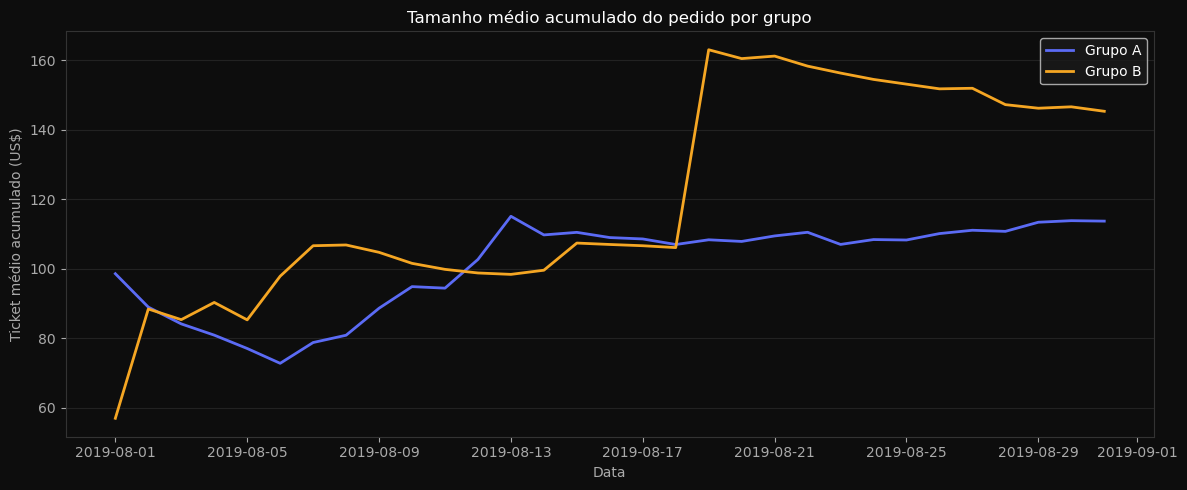

In [14]:
# Tamanho médio acumulado = revenue / orders (ambos já acumulados no cumulativeData).
# Reaproveito os cumulativeRevenueA/B que separei na 2.1.
# utilizando meu estilo de plotagem

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.plot(cumulativeRevenueA['date'],
        cumulativeRevenueA['revenue'] / cumulativeRevenueA['orders'],
        color='#5B6BF5', linewidth=2, label='Grupo A')
ax.plot(cumulativeRevenueB['date'],
        cumulativeRevenueB['revenue'] / cumulativeRevenueB['orders'],
        color='#F5A623', linewidth=2, label='Grupo B')

ax.set_title('Tamanho médio acumulado do pedido por grupo', color='white')
ax.set_xlabel('Data', color='#aaaaaa')
ax.set_ylabel('Ticket médio acumulado (US$)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.yaxis.grid(True, color='#222222', zorder=0)
ax.set_axisbelow(True)
ax.legend(facecolor='#1a1a1a', labelcolor='white')

plt.tight_layout()
plt.show()


In [15]:
# Aqui farei uma análise de sensibilidade,
# O ticket médio maior do B é real ou é o mesmo outlier de 19/08 reaparecendo?
# Vou remover e checar

# 1. Ticket médio acumulado no fim do teste
avg_A = cumulativeRevenueA['revenue'].iloc[-1] / cumulativeRevenueA['orders'].iloc[-1]
avg_B = cumulativeRevenueB['revenue'].iloc[-1] / cumulativeRevenueB['orders'].iloc[-1]
print(f'Ticket médio final | A: US$ {avg_A:.2f} | B: US$ {avg_B:.2f} '
    f'(B é {avg_B/avg_A - 1:.1%} maior)')

# 2. O salto: ticket médio de A e B lado a lado, antes e depois de 19/08
salto_A = cumulativeRevenueA.copy()
salto_A['ticket'] = salto_A['revenue'] / salto_A['orders']
salto_B = cumulativeRevenueB.copy()
salto_B['ticket'] = salto_B['revenue'] / salto_B['orders']

salto = salto_A[['date', 'ticket']].merge(
    salto_B[['date', 'ticket']], on='date', suffixes=('_A', '_B'))

print('\nTicket médio acumulado de A e B (13 a 20/08):')
print(salto[(salto['date'] >= '2019-08-13') & (salto['date'] <= '2019-08-20')]
    .round(2).to_string(index=False))

# 3. E se eu tirar o único pedido de 19.920,40?
maior = orders[orders['group'] == 'B']['revenue'].max()
rev_B = cumulativeRevenueB['revenue'].iloc[-1]
ord_B = cumulativeRevenueB['orders'].iloc[-1]
avg_B_sem = (rev_B - maior) / (ord_B - 1)
print(f'\nTicket médio do B SEM o pedido de US$ {maior:,.2f}: US$ {avg_B_sem:.2f}')
print(f'  → contra US$ {avg_A:.2f} do A: agora B fica {avg_B_sem/avg_A - 1:+.1%} vs A '
    f'({"acima" if avg_B_sem > avg_A else "ABAIXO"}).')


Ticket médio final | A: US$ 113.70 | B: US$ 145.35 (B é 27.8% maior)

Ticket médio acumulado de A e B (13 a 20/08):
      date  ticket_A  ticket_B
2019-08-13    115.10     98.36
2019-08-14    109.73     99.56
2019-08-15    110.47    107.38
2019-08-16    108.96    106.97
2019-08-17    108.57    106.61
2019-08-18    106.96    106.07
2019-08-19    108.33    163.07
2019-08-20    107.85    160.53

Ticket médio do B SEM o pedido de US$ 19,920.40: US$ 109.20
  → contra US$ 113.70 do A: agora B fica -4.0% vs A (ABAIXO).


**📝 Conclusão 2.2:** 

De 15 a 18/08 o ticket médio acumulado dos dois grupos converge para a mesma faixa (~US$ 106-108) — antes disso, nos primeiros dias, B chega a ficar abaixo de A. Em 19/08 a curva de B dá um salto vertical, de ~106 para ~163, e daí em diante fica permanentemente acima de A, fechando o mês em US$ 145,35 contra US$ 113,70 (+27,8%).

Esse salto é o mesmo pedido de US$ 19.920,40 da 2.1 reaparecendo. Removendo-o, o ticket médio de B cai para US$ 109,20 e passa a ficar 4% ABAIXO de A. A vantagem de ticket médio do B não é uma tendência — é inteiramente sustentada por uma única compra.

Concluo que não há evidência de que o grupo B tenha um ticket médio maior. O que o gráfico mostra é a sensibilidade da média a um outlier. Isso antecipa e reforça a necessidade dos passos 2.6–2.8 (definir o corte de anomalia) e da reavaliação com dados filtrados na 2.12.

### 2.3 Diferença relativa do tamanho médio acumulado (B vs A)

Vou traçar a **diferença relativa** do tamanho médio acumulado do pedido do grupo **B em relação ao A**.

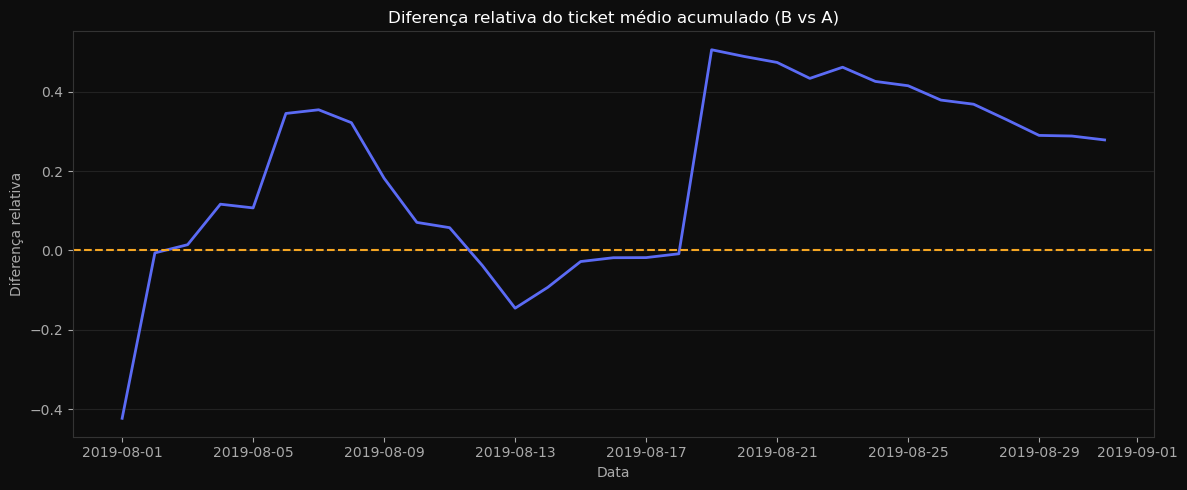

In [16]:
# 1. Juntarei A e B por data:
# merged = cumulativeRevenueA.merge(cumulativeRevenueB, on='date', suffixes=['A','B'])
# 2. Ploto a razão -1:
#    (revenueB/ordersB) / (revenueA/ordersA) - 1
# Usando meu estilo de plotagem, com linha de referência em 0

merged = cumulativeRevenueA.merge(cumulativeRevenueB, on='date', suffixes=('A', 'B'))
merged['ticketA'] = merged['revenueA'] / merged['ordersA']
merged['ticketB'] = merged['revenueB'] / merged['ordersB']
merged['diff_rel'] = merged['ticketB'] / merged['ticketA'] - 1

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.plot(merged['date'], merged['diff_rel'], color='#5B6BF5', linewidth=2)
ax.axhline(y=0, color='#F5A623', linestyle='--', linewidth=1.5)

ax.set_title('Diferença relativa do ticket médio acumulado (B vs A)', color='white')
ax.set_xlabel('Data', color='#aaaaaa')
ax.set_ylabel('Diferença relativa', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.yaxis.grid(True, color='#222222', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [17]:
# Evidentemente, o pico da diferença relativa é no dia 19/08, e a curva vem caindo desde então.
pico = merged.loc[merged['diff_rel'].idxmax()]
final = merged.iloc[-1]
print(f'Pico da diferença relativa: {pico["diff_rel"]:+.1%} em {pico["date"].date()}')
print(f'Valor final (31/08)       : {final["diff_rel"]:+.1%}')
print(f'\nOu seja: o pico é {pico["diff_rel"] - final["diff_rel"]:.1%} maior que o valor final —'
    f' a curva vem CAINDO desde 19/08, diluída pelos pedidos seguintes.')

Pico da diferença relativa: +50.5% em 2019-08-19
Valor final (31/08)       : +27.8%

Ou seja: o pico é 22.7% maior que o valor final — a curva vem CAINDO desde 19/08, diluída pelos pedidos seguintes.


**📝 Conclusão 2.3:**  

A curva passa a maior parte do tempo perto de zero, com uma oscilação pequena pra baixo e pra cima nos primeiros dias — nada que chame atenção. Aí em 19/08 ela dispara pra +50,5%, o pico do gráfico inteiro, e é o mesmo pedido de US$ 19.920,40 que já apareceu na 2.1 e na 2.2 batendo de novo.

O que chama atenção aqui é o formato depois do pico: em vez de ficar estacionada em +50%, a linha vai caindo aos poucos — +50,5% no dia do salto, +27,8% no fim do mês. Isso é diluição pura: cada pedido novo que entra em B (e não é de US$ 19 mil) puxa a média de volta pra baixo. Um salto vertical seguido de queda suave é praticamente a assinatura visual de "um outlier isolado", não de uma vantagem real de B que estivesse crescendo aos poucos.

Juntando com o que já tenho: não há motivo pra acreditar que o ticket médio de B é maior. É um pedido só, distorcendo tudo para o grupo B. 

### 2.4 Taxa de conversão dos dois grupos

Vou calcular e traçar a **taxa de conversão** (pedidos ÷ visitas) de cada grupo.

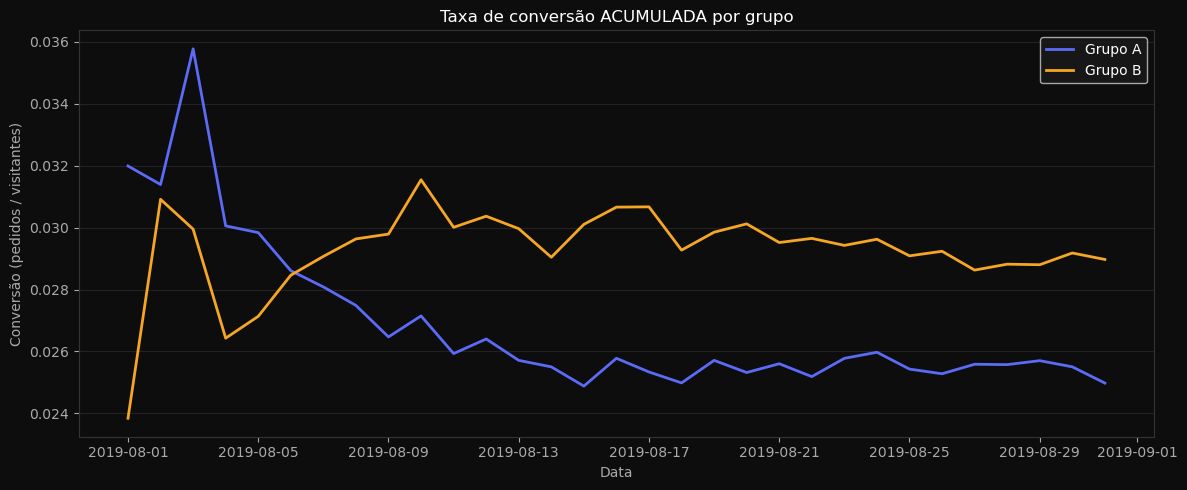

In [18]:
# Conversão = pedidos / visitas. Aqui pode usar a conversão ACUMULADA (orders/visitors do
# cumulativeData) ou a conversão DIÁRIA (pedidos por dia / visitas por dia)
# Vamos optar pela cumulativa para visualizar com mais expressão no gráfico

# ===== CONVERSÃO ACUMULADA =====
cumulativeRevenueA_conv = cumulativeRevenueA.assign(
    conversion=cumulativeRevenueA['orders'] / cumulativeRevenueA['visitors'])
cumulativeRevenueB_conv = cumulativeRevenueB.assign(
    conversion=cumulativeRevenueB['orders'] / cumulativeRevenueB['visitors'])

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.plot(cumulativeRevenueA_conv['date'], cumulativeRevenueA_conv['conversion'],
        color='#5B6BF5', linewidth=2, label='Grupo A')
ax.plot(cumulativeRevenueB_conv['date'], cumulativeRevenueB_conv['conversion'],
        color='#F5A623', linewidth=2, label='Grupo B')

ax.set_title('Taxa de conversão ACUMULADA por grupo', color='white')
ax.set_xlabel('Data', color='#aaaaaa')
ax.set_ylabel('Conversão (pedidos / visitantes)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.yaxis.grid(True, color='#222222', zorder=0)
ax.set_axisbelow(True)
ax.legend(facecolor='#1a1a1a', labelcolor='white')

plt.tight_layout()
plt.show()

In [19]:
# Exibindo os valores de conversão acumulada dos dois grupos, arredondados para 4 casas decimais
# Justamente mostrando onde se inverte a liderança

conv_lado_a_lado = cumulativeRevenueA_conv[['date', 'conversion']].merge(
    cumulativeRevenueB_conv[['date', 'conversion']], on='date', suffixes=('_A', '_B'))

print(conv_lado_a_lado.head(10).round(4).to_string(index=False))
print()
print(conv_lado_a_lado.tail(5).round(4).to_string(index=False))

      date  conversion_A  conversion_B
2019-08-01        0.0320        0.0238
2019-08-02        0.0314        0.0309
2019-08-03        0.0358        0.0300
2019-08-04        0.0301        0.0264
2019-08-05        0.0298        0.0271
2019-08-06        0.0286        0.0285
2019-08-07        0.0281        0.0291
2019-08-08        0.0275        0.0296
2019-08-09        0.0265        0.0298
2019-08-10        0.0271        0.0315

      date  conversion_A  conversion_B
2019-08-27        0.0256        0.0286
2019-08-28        0.0256        0.0288
2019-08-29        0.0257        0.0288
2019-08-30        0.0255        0.0292
2019-08-31        0.0250        0.0290


**📝 Conclusão 2.4:**  

Nos primeiros dias A vinha na frente — chega a 3,58% em 03/08 contra 3,00% de B. Só que essa vantagem não dura: entre os dias 06/08 e 07/08 as curvas se cruzam e B assume, sem nunca mais devolver a liderança dali em diante.

Depois do cruzamento as duas séries meio que "acomodam": a partir de 16/08 A oscila muito pouco em torno de 2,55%, e B em torno de 2,95% — os dois praticamente viram retas paralelas até o fim do mês. Fecha em 2,50% (A) contra 2,90% (B), uma diferença de 16%.

Diferente da receita e do ticket médio, aqui não tem outlier estragando a leitura (já vimos isso ao checar a conversão diária: 19/08 não tem nada fora do padrão). Isso é bom sinal — dá pra confiar mais nessa diferença de 16% do que nos números de receita/ticket médio. Ainda assim, falta testar se é estatisticamente significante ou se é só ruído para análise concreta.

### 2.5 Diferença relativa na conversão acumulada (B vs A)

Vou traçar a **diferença relativa na conversão acumulada** do grupo **B em relação ao A**.

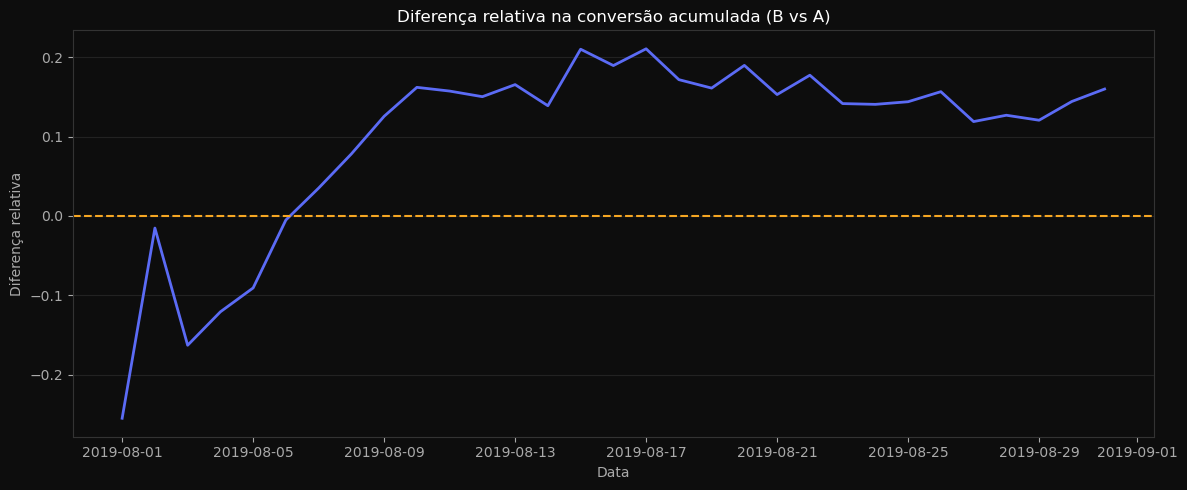

In [20]:
# Junte conversão acumulada de A e B por data e plote (convB/convA - 1).
# Usarei novamente meu estilo de plotagem, com linha de referência em 0

merged_conv = cumulativeRevenueA.merge(cumulativeRevenueB, on='date', suffixes=('A', 'B'))
merged_conv['convA'] = merged_conv['ordersA'] / merged_conv['visitorsA']
merged_conv['convB'] = merged_conv['ordersB'] / merged_conv['visitorsB']
merged_conv['diff_rel'] = merged_conv['convB'] / merged_conv['convA'] - 1

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.plot(merged_conv['date'], merged_conv['diff_rel'], color='#5B6BF5', linewidth=2)
ax.axhline(y=0, color='#F5A623', linestyle='--', linewidth=1.5)

ax.set_title('Diferença relativa na conversão acumulada (B vs A)', color='white')
ax.set_xlabel('Data', color='#aaaaaa')
ax.set_ylabel('Diferença relativa', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.yaxis.grid(True, color='#222222', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [21]:
# Tirando a evidência mais uma vez:
# Quantifico o que vi no gráfico: quando B ultrapassa A, qual foi o pico,
# e se a diferença se mantém estável na segunda metade do mês.

# 1. Primeira data em que diff_rel fica positivo = dia em que B ultrapassa A
print('Primeiro dia em que B ultrapassa A:',
    merged_conv[merged_conv['diff_rel'] > 0].iloc[0]['date'].date())

# 2. Maior valor da diferença relativa (o pico da curva) e em que data ele ocorre
#    idxmax() pega o ÍNDICE da linha do máximo, uso ele pra buscar a data correspondente
print('Pico:', f"{merged_conv['diff_rel'].max():+.1%}",
    'em', merged_conv.loc[merged_conv['diff_rel'].idxmax(), 'date'].date())

# 3. Valor no último dia do teste (31/08)
print('Valor final (31/08):', f"{merged_conv['diff_rel'].iloc[-1]:+.1%}")

# 4. Filtro só a segunda metade do mês (>= 16/08) pra medir se a diferença
#    já estabilizou: média mostra o patamar, desvio padrão mostra o quanto oscila
seg_metade = merged_conv[merged_conv['date'] >= '2019-08-16']
print(f"\nSegunda metade do mês: média = {seg_metade['diff_rel'].mean():+.1%}, "
    f"desvio = {seg_metade['diff_rel'].std():.1%}")

Primeiro dia em que B ultrapassa A: 2019-08-07
Pico: +21.0% em 2019-08-17
Valor final (31/08): +16.0%

Segunda metade do mês: média = +15.7%, desvio = 2.6%


**📝 Conclusão 2.5:** 

A curva cruza o zero exatamente em 07/08 — dia em que a conversão de B ultrapassa a de A — e sobe até um pico de +21,0% em 17/08. Dali em diante ela não desaba feito na 2.3: na segunda metade do mês a diferença fica estável, com média de +15,7% e desvio de só 2,6 pontos percentuais, fechando o mês em +16,0%.

Essa estabilidade é o que diferencia essa métrica de receita e ticket médio: lá, tudo dependia de um pedido só; aqui a curva sobe devagar até o pico e depois se acomoda sozinha, sem nenhum evento pontual puxando o número. Isso é bem mais parecido com um efeito real do teste do que com ruído de outlier.

Ainda falta confirmar com o teste de significância (2.9), mas visualmente essa é, de longe, a métrica mais convincente a favor do grupo B até agora.

### 2.6 Percentis 95 e 99 de pedidos por usuário

Vou calcular os **percentis 95 e 99** do número de pedidos por usuário para definir a partir de onde um ponto vira **anomalia**.

In [30]:
# 1. Organizando Nº de pedidos por usuário:
pedidos_por_usuario = orders.groupby('visitorId')['transactionId'].count()

# 2. Percentis 95 e 99:
# np.percentile

p95, p99 = np.percentile(pedidos_por_usuario, [95, 99])
print(f'Percentil 95: {p95:.0f} pedidos | Percentil 99: {p99:.0f} pedidos')

# 3. Defino a partir de quantos pedidos um usuário vira ANOMALIA (o valor vou guardar pode ser útil).
#  Distribuição completa, pra ver o quão discreta ela é

print('\nDistribuição de pedidos por usuário:')
print(pedidos_por_usuario.value_counts().sort_index().to_string())


Percentil 95: 1 pedidos | Percentil 99: 2 pedidos

Distribuição de pedidos por usuário:
transactionId
1    937
2     29
3      7


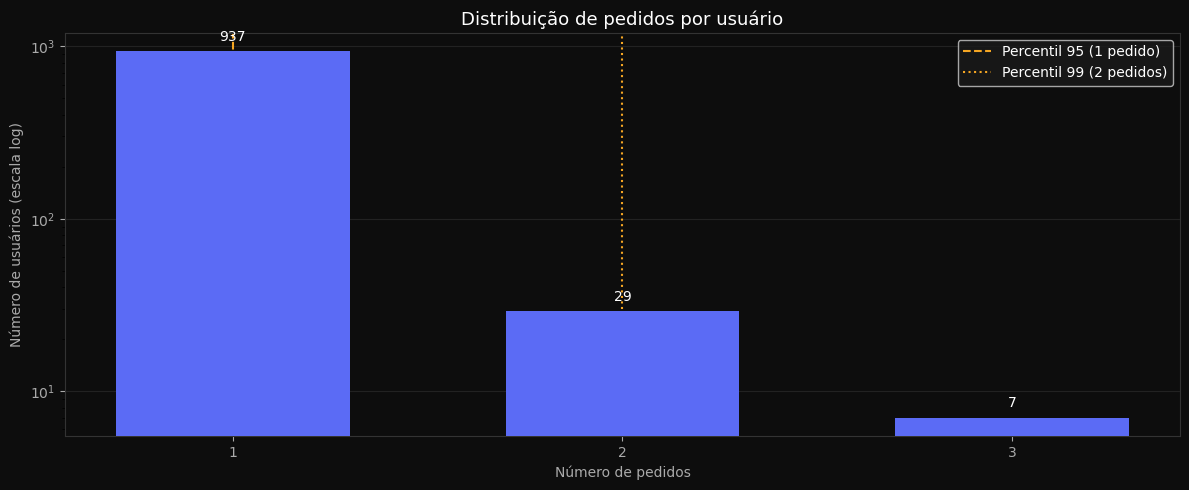

In [31]:
# 4. Gráfico da distribuição de pedidos por usuário, com os percentis marcados

distribuicao = pedidos_por_usuario.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.bar(distribuicao.index, distribuicao.values, color='#5B6BF5', zorder=3, width=0.6)

# Anota a quantidade de usuários em cima de cada barra (as barras de 2 e 3
# pedidos ficam bem pequenas perto da de 1, então o rótulo ajuda a ler)

for x, y in zip(distribuicao.index, distribuicao.values):
    ax.text(x, y * 1.15, str(y), ha='center', color='white', fontsize=10)

# Linhas verticais marcando onde caem os percentis 95 e 99
ax.axvline(x=p95, color='#F5A623', linestyle='--', linewidth=1.5, label=f'Percentil 95 ({p95:.0f} pedido)')
ax.axvline(x=p99, color='#F5A623', linestyle=':', linewidth=1.5, label=f'Percentil 99 ({p99:.0f} pedidos)')

ax.set_yscale('log')  # escala log pra 7 não sumir do lado de 937
ax.set_title('Distribuição de pedidos por usuário', color='white', fontsize=13)
ax.set_xlabel('Número de pedidos', color='#aaaaaa')
ax.set_ylabel('Número de usuários (escala log)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_color('#333333')
ax.yaxis.grid(True, color='#222222', zorder=0)
ax.set_axisbelow(True)
ax.set_xticks(distribuicao.index)
ax.legend(facecolor='#1a1a1a', labelcolor='white')

plt.tight_layout()
plt.show()

**📝 Conclusão 2.6:** 

A distribuição de pedidos por usuário é bem concentrada: dos 973 usuários, 937 fizeram só 1 pedido, 29 fizeram 2, e apenas 7 chegaram a 3 pedidos. Isso explica os percentis: até o percentil 95, o usuário típico ainda está em apenas 1 pedido — só a partir do percentil 99 aparece o valor 2. Ou seja, ter mais de um pedido já é raro o suficiente pra ficar fora da maioria esmagadora da base. E para 3 pedidos, acaba sendo fora da curva mesmo.

Com esse cenário, considero anomalia o usuário com mais de 2 pedidos (ou seja, 3 pedidos, o teto observado nos dados). São só 7 usuários nessa faixa, o que reforça que é um comportamento realmente atípico e não um padrão comum de recompra. Vou guardar esse corte (>2 pedidos) pra usar no filtro de anomalias do passo 2.11, poderá ser útil.

Com o gráfico, fica ainda mais exposto a discrepância de pedidos.

### 2.7 Gráfico de dispersão dos preços dos pedidos

Vou traçar um **gráfico de dispersão** dos valores dos pedidos para enxergar os outliers.

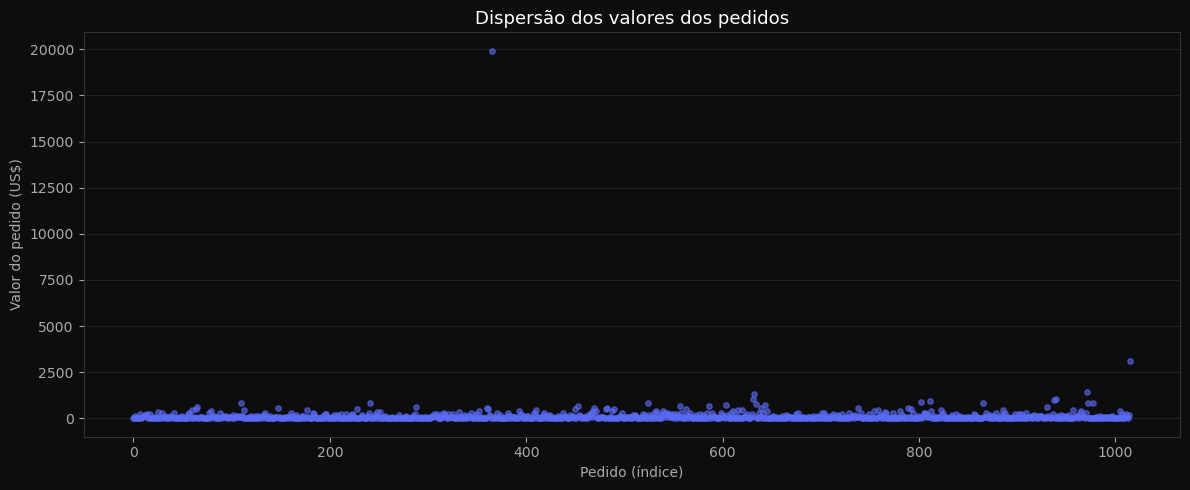

In [32]:
# Scatter dos valores (revenue) dos pedidos.
# x = np.arange(len(orders))

x = np.arange(len(orders))

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.scatter(x, orders['revenue'], color='#5B6BF5', s=15, alpha=0.6, zorder=3)

ax.set_title('Dispersão dos valores dos pedidos', color='white', fontsize=13)
ax.set_xlabel('Pedido (índice)', color='#aaaaaa')
ax.set_ylabel('Valor do pedido (US$)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_color('#333333')
ax.yaxis.grid(True, color='#222222', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()



In [34]:
# Temos um gráfico anterior bem concentrado numa faixa de valor similar
# Alguns números pra apoiar a conclusão

print('Total de pedidos:', len(orders))
print('Maior valor de pedido: US$', orders['revenue'].max())
print('Média: US$', round(orders['revenue'].mean(), 2))
print('Mediana: US$', orders['revenue'].median())

Total de pedidos: 1016
Maior valor de pedido: US$ 19920.4
Média: US$ 130.77
Mediana: US$ 50.1


**📝 Conclusão 2.7:** 

O gráfico deixa claro que quase todos os 1016 pedidos ficam concentrados numa faixa baixa e parecida de valores, bem próxima ao eixo x — é isso que a mediana de US$ 50,10 reflete, o "pedido típico" da base. Só que a média fica em US$ 130,77, mais de 2,5x a mediana, e essa distância enorme entre as duas só se explica por um ponto isolado lá em cima: o pedido de US$ 19.920,40, que aparece completamente separado da nuvem de pontos.

Isso é a assinatura clássica de outlier: quando os valores estão concentrados e similares, média e mediana deveriam ficar próximas; aqui elas se afastam porque uma única observação extrema está puxando a média pra cima sozinha. Reforça o que já vinha aparecendo desde 2.1/2.2 — esse pedido específico é o que precisa ser isolado nos cortes de anomalia da 2.8 em diante.

### 2.8 Percentis 95 e 99 dos preços dos pedidos

Vou calcular os **percentis 95 e 99** dos valores dos pedidos para definir o ponto de **anomalia**.

In [37]:
# 1. Percentis 95 e 99 do valor dos pedidos

p95_valor = np.percentile(orders['revenue'], 95)
p99_valor = np.percentile(orders['revenue'], 99)
print(f'Percentil 95: US$ {p95_valor:.2f} | Percentil 99: US$ {p99_valor:.2f}\n')

# 2. Quantos pedidos ficam acima de cada corte
acima_95 = (orders['revenue'] > p95_valor).sum()
acima_99 = (orders['revenue'] > p99_valor).sum()
print(f'Pedidos acima do p95: {acima_95} ({acima_95/len(orders):.1%})')
print(f'Pedidos acima do p99: {acima_99} ({acima_99/len(orders):.1%})')

Percentil 95: US$ 414.27 | Percentil 99: US$ 830.30

Pedidos acima do p95: 51 (5.0%)
Pedidos acima do p99: 9 (0.9%)


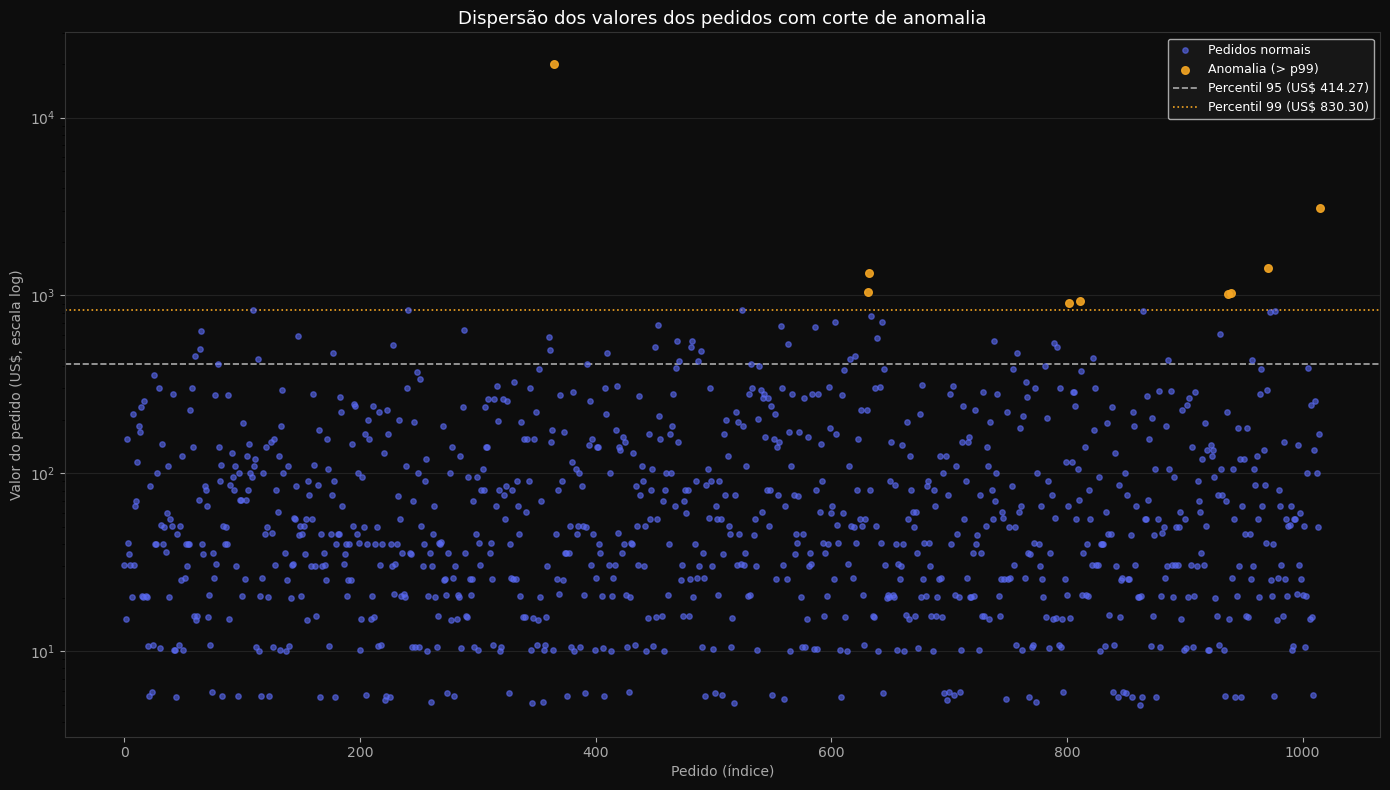

Pedidos anômalos (> p99): 9 (0.9%)


In [41]:
# Gráfico de dispersão destacando as anomalias (> percentil 99)
# Mesmo estilo de plotagem, mas agora destaco os pedidos acima do p99 com outra cor 
# e tamanho de ponto.

x = np.arange(len(orders))
anomalo = orders['revenue'] > p99_valor

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.scatter(x[~anomalo], orders['revenue'][~anomalo], color='#5B6BF5', s=15, alpha=0.6, zorder=3, label='Pedidos normais')
ax.scatter(x[anomalo], orders['revenue'][anomalo], color='#F5A623', s=30, alpha=0.9, zorder=4, label='Anomalia (> p99)')

ax.axhline(y=p95_valor, color='#aaaaaa', linestyle='--', linewidth=1.2, label=f'Percentil 95 (US$ {p95_valor:.2f})')
ax.axhline(y=p99_valor, color='#F5A623', linestyle=':', linewidth=1.2, label=f'Percentil 99 (US$ {p99_valor:.2f})')

ax.set_yscale('log')  # escala log pra caber o outlier de US$ 19.920 no mesmo gráfico
ax.set_title('Dispersão dos valores dos pedidos com corte de anomalia', color='white', fontsize=13)
ax.set_xlabel('Pedido (índice)', color='#aaaaaa')
ax.set_ylabel('Valor do pedido (US$, escala log)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_color('#333333')
ax.yaxis.grid(True, color='#222222', zorder=0)
ax.set_axisbelow(True)
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.show()

# Comprova em números o que o gráfico mostra
print(f'Pedidos anômalos (> p99): {anomalo.sum()} ({anomalo.mean():.1%})')

**📝 Conclusão 2.8:** 

O corte no p99 (US$ 830,30) isola 9 pedidos como anômalos — 0,9% do total —, um recorte parecido em proporção com o que já tinha usado na 2.6 (0,7% pra usuários com mais de 2 pedidos). No gráfico dá pra ver que esses 9 pontos ficam claramente separados da nuvem principal, e olhando com mais atenção, o outlier de US$ 19.920,40 nem fica perto dos outros 8 — ele está uma ordem de grandeza acima até do que já é considerado caro dentro do grupo anômalo.

Vou usar US$ 830,30 (p99) como corte pra pedido caro, junto com o corte de >2 pedidos da 2.6, pra filtrar as anomalias nos testes de significância da 2.11 e 2.12.

### 2.9 Significância na conversão — dados BRUTOS

Vou calcular a **significância estatística** da diferença de **conversão** entre os grupos usando os **dados brutos**.

In [44]:
# Teste de Mann-Whitney U.  H0: não há diferença na conversão entre A e B.
# Vou usar o padrão de alpha = 0.05, ou seja, se p < 0.05 rejeito H0 e 
# concluo que há diferença significativa.
alpha = 0.05

visitantesA = visits[visits['group']=='A']['visits'].sum()
visitantesB = visits[visits['group']=='B']['visits'].sum()
pedidosPorUserA = orders[orders['group']=='A'].groupby('visitorId')['transactionId'].count()
pedidosPorUserB = orders[orders['group']=='B'].groupby('visitorId')['transactionId'].count()

amostraA = pd.concat([pedidosPorUserA, pd.Series(0, index=np.arange(visitantesA - len(pedidosPorUserA)))])
amostraB = pd.concat([pedidosPorUserB, pd.Series(0, index=np.arange(visitantesB - len(pedidosPorUserB)))])

# uso p = stats.mannwhitneyu(amostraA, amostraB)[1]
# Comparo p com alpha e imprima a diferença relativa de conversão (mediaB/mediaA - 1).

p_value = stats.mannwhitneyu(amostraA, amostraB)[1]
diferenca_relativa = amostraB.mean() / amostraA.mean() - 1

print(f'p-valor: {p_value:.4f}')
print(f'Diferença relativa na conversão (B vs A): {diferenca_relativa:+.1%}')

if p_value < alpha:
    print('Rejeitando a hipótese nula: há diferença significativa entre as taxas de conversão')
else:
    print('Falha ao rejeitar a hipótese nula: não há motivo para considerar as taxas de conversão diferentes')

p-valor: 0.0110
Diferença relativa na conversão (B vs A): +16.0%
Rejeitando a hipótese nula: há diferença significativa entre as taxas de conversão


**📝 Conclusão 2.9:** 

O teste deu p-value de 0,0110, abaixo do alpha de 0,05 — isso prova que a diferença de +16,0% na conversão entre B e A não é fruto do acaso, é estatisticamente significativa mesmo nos dados brutos, com o outlier ainda dentro da base. Bate com o que o gráfico da 2.5 já vinha sugerindo: essa é a métrica mais sólida a favor do grupo B até aqui.

### 2.10 Significância no tamanho médio do pedido — dados BRUTOS

Vou calcular a **significância estatística** da diferença no **tamanho médio do pedido** usando os **dados brutos**.

In [ ]:
# Mann-Whitney U.  H0: não há diferença no tamanho médio do pedido entre A e B.

revenueA = orders[orders['group']=='A']['revenue']
revenueB = orders[orders['group']=='B']['revenue']

# Comparo com alpha e imprimo a diferença relativa (mediaB/mediaA - 1).
p_value = stats.mannwhitneyu(revenueA, revenueB)[1]
diferenca_relativa = revenueB.mean() / revenueA.mean() - 1

print(f'p-valor: {p_value:.4f}')
print(f'Diferença relativa no ticket médio (B vs A): {diferenca_relativa:+.1%}')

if p_value < alpha:
    print('Rejeitando a hipótese nula: há diferença significativa no tamanho médio do pedido')
else:
    print('Falha ao rejeitar a hipótese nula: não há motivo para considerar o tamanho médio do pedido diferente')

p-valor: 0.8622
Diferença relativa no ticket médio (B vs A): +27.8%
Falha ao rejeitar a hipótese nula: não há motivo para considerar o tamanho médio do pedido diferente


**📝 Conclusão 2.10:** 

Para o ticket médio temos que o p-value foi de 0,8622, bem acima do alpha de 0,05 — isso prova o oposto: não há evidência estatística de que o ticket médio de B seja realmente maior que o de A. O +27,8% de diferença nominal que aparece nos números não se sustenta estatisticamente; é exatamente o que a análise da 2.1/2.2 já apontava, o outlier de US$ 19.920,40 criando uma diferença que desaparece quando se testa a distribuição como um todo, e não só a média. Não foi preciso plotar novamente, os gráficos anteriores já plotados, comprovam o que o conclui no passo 2.9 e 2.10

### 2.11 Significância na conversão — dados FILTRADOS

Vou repetir o teste de **conversão**, agora com os **dados filtrados** (sem as anomalias).

In [48]:
# Aqui repito 2.9 removendo ANOMALIAS: usuários com muitos pedidos (2.6) e pedidos caros (2.8).
# onde tenho: usuarios_anomalos = pedidos_por_usuario[pedidos_por_usuario > corte_2_6].index
# pedidos_caros = orders[orders['revenue'] > corte_2_8]

corte_2_6 = 2       # anomalia = usuário com mais de 2 pedidos (definido na 2.6)
corte_2_8 = 830.30  # anomalia = pedido acima do percentil 99 (definido na 2.8)

usuarios_anomalos = pedidos_por_usuario[pedidos_por_usuario > corte_2_6].index
pedidos_caros = orders[orders['revenue'] > corte_2_8]

# Agora filtro orders; recalculo amostraA/amostraB; rodo Mann-Whitney; comparo com alpha.

ordersFiltrado = orders[~orders['visitorId'].isin(usuarios_anomalos) & ~orders['revenue'].gt(corte_2_8)]

print(f'Usuários anômalos removidos (>{corte_2_6} pedidos): {len(usuarios_anomalos)}')
print(f'Pedidos caros removidos (>{corte_2_8}): {len(pedidos_caros)}')
print(f'Pedidos: {len(orders)} -> {len(ordersFiltrado)} após filtro\n')

pedidosPorUserA = ordersFiltrado[ordersFiltrado['group']=='A'].groupby('visitorId')['transactionId'].count()
pedidosPorUserB = ordersFiltrado[ordersFiltrado['group']=='B'].groupby('visitorId')['transactionId'].count()

amostraA = pd.concat([pedidosPorUserA, pd.Series(0, index=np.arange(visitantesA - len(pedidosPorUserA)))])
amostraB = pd.concat([pedidosPorUserB, pd.Series(0, index=np.arange(visitantesB - len(pedidosPorUserB)))])

p_value = stats.mannwhitneyu(amostraA, amostraB)[1]
diferenca_relativa = amostraB.mean() / amostraA.mean() - 1

print(f'p-valor: {p_value:.4f}')
print(f'Diferença relativa na conversão (B vs A): {diferenca_relativa:+.1%}')

if p_value < alpha:
    print('Rejeitando a hipótese nula: há diferença significativa entre as taxas de conversão')
else:
    print('Falha ao rejeitar a hipótese nula: não há motivo para considerar as taxas de conversão diferentes')

Usuários anômalos removidos (>2 pedidos): 7
Pedidos caros removidos (>830.3): 9
Pedidos: 1016 -> 986 após filtro

p-valor: 0.0070
Diferença relativa na conversão (B vs A): +18.9%
Rejeitando a hipótese nula: há diferença significativa entre as taxas de conversão


**📝 Conclusão 2.11:** 

Mesmo depois de tirar os 7 usuários anômalos (>2 pedidos) e os 9 pedidos caros (>US$ 830,30), o p-valor continua bem abaixo de 0,05 (0,0070) — ou seja, a diferença na conversão não vem das anomalias, ela se mantém mesmo com os dados limpos. A diferença relativa até cresce um pouco, de +16,0% (2.9, dados brutos) para +18,9% aqui, o que reforça que esse efeito é real e não um artefato dos outliers.

Isso confirma o que a 2.5 e a 2.9 já vinham apontando: a vantagem de conversão do grupo B é sólida e resiste à remoção das anomalias. Cria-se assim, o ponto da vantagem de B real e testado.

### 2.12 Significância no tamanho médio do pedido — dados FILTRADOS

Vou repetir o teste do **tamanho médio do pedido**, agora com os **dados filtrados**.

In [49]:
# Igual 2.10, mas usando apenas os pedidos NÃO anômalos (sem os caros/usuários anômalos).
revenueFiltradoA = ordersFiltrado[ordersFiltrado['group']=='A']['revenue']
revenueFiltradoB = ordersFiltrado[ordersFiltrado['group']=='B']['revenue']

# p = stats.mannwhitneyu(revenueFiltradoA, revenueFiltradoB)[1]
p_value = stats.mannwhitneyu(revenueFiltradoA, revenueFiltradoB)[1]
diferenca_relativa = revenueFiltradoB.mean() / revenueFiltradoA.mean() - 1

print(f'p-valor: {p_value:.4f}')
print(f'Diferença relativa no ticket médio (B vs A): {diferenca_relativa:+.1%}')

if p_value < alpha:
    print('Rejeitando a hipótese nula: há diferença significativa no tamanho médio do pedido')
else:
    print('Falha ao rejeitar a hipótese nula: não há motivo para considerar o tamanho médio do pedido diferente')

p-valor: 0.8220
Diferença relativa no ticket médio (B vs A): -3.2%
Falha ao rejeitar a hipótese nula: não há motivo para considerar o tamanho médio do pedido diferente


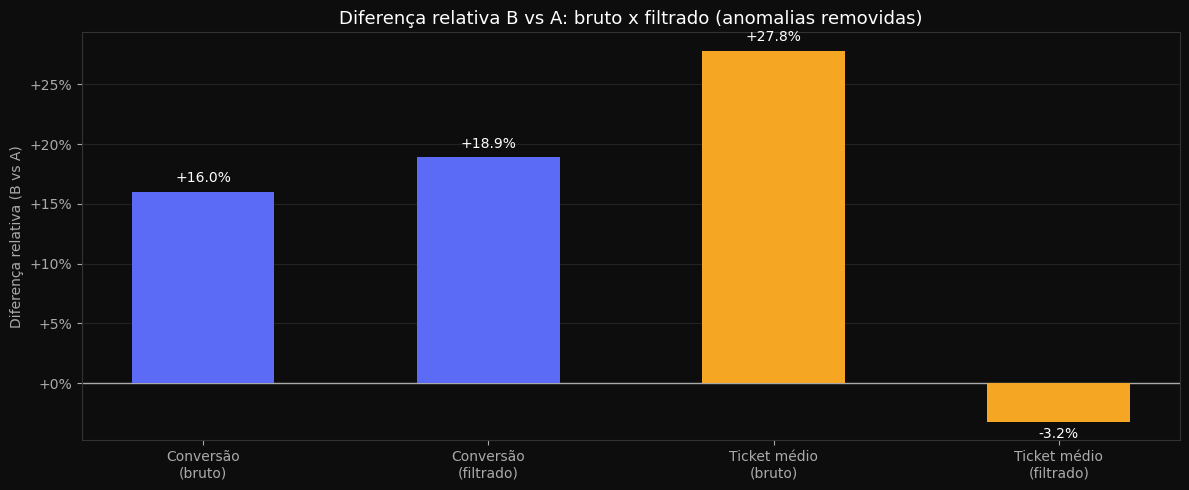

In [50]:
# Resumo: diferença relativa B vs A, bruto x filtrado, nas duas métricas testadas.
# Vou plotar e comparar

labels = ['Conversão\n(bruto)', 'Conversão\n(filtrado)', 'Ticket médio\n(bruto)', 'Ticket médio\n(filtrado)']
valores = [0.160, 0.189, 0.278, -0.032]  # números das conclusões 2.9, 2.11, 2.10, 2.12
cores = ['#5B6BF5', '#5B6BF5', '#F5A623', '#F5A623']

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

barras = ax.bar(labels, valores, color=cores, zorder=3, width=0.5)

for barra, valor in zip(barras, valores):
    y = barra.get_height()
    offset = 0.008 if y >= 0 else -0.014
    ax.text(barra.get_x() + barra.get_width()/2, y + offset, f'{valor:+.1%}', ha='center', color='white', fontsize=10)

ax.axhline(y=0, color='#aaaaaa', linewidth=1, zorder=2)

ax.set_title('Diferença relativa B vs A: bruto x filtrado (anomalias removidas)', color='white', fontsize=13)
ax.set_ylabel('Diferença relativa (B vs A)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_color('#333333')
ax.yaxis.grid(True, color='#222222', zorder=0)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(lambda x, _: f'{x:+.0%}')

plt.tight_layout()
plt.show()

**📝 Conclusão 2.12:** 

Com as anomalias fora, o p-valor sobe pra 0,8220 — ainda mais longe de significância do que na 2.10 — e a diferença relativa não só encolhe como troca de sinal: de +27,8% (bruto) para -3,2% (filtrado). Ou seja, sem o pedido de US$ 19.920,40 e os demais valores anômalos, B fica ligeiramente abaixo de A, não acima. Falha ao rejeitar H0 confirma que essa diferença de -3,2% também não é estatisticamente relevante, é só ruído.

O gráfico-resumo deixa isso bem exposto: enquanto a barra de conversão se mantém praticamente no mesmo patamar do bruto pro filtrado (e ainda cresce um pouco), a barra do ticket médio despenca e vira negativa — visualmente é a prova de que a vantagem de receita/ticket que via nos primeiros passos (2.1, 2.2) era inteiramente sustentada pelos outliers, e a de conversão não. Sendo assim, temos dados mais que suficientes para uma conclusão reforçada na 2.13.

### 2.13 Decisão final

Com base em tudo o que analisei (gráficos acumulados + testes de significância nos dados brutos e
filtrados), vou tomar minha decisão. As opções são:

1. **Parar o teste** e considerar um dos grupos o **líder**.
2. **Parar o teste** e concluir que **não há diferença** entre os grupos.
3. **Continuar o teste.**

In [51]:
# Monto uma tabela-resumo dos 4 testes para embasar a minha decisão visualmente:
# métrica | dados (bruto/filtrado) | p-valor | rejeita H0? | dif. relativa
# display(resumo)

resumo = pd.DataFrame([
    ['Conversão', 'Bruto', 0.0110, True, '+16.0%'],
    ['Conversão', 'Filtrado', 0.0070, True, '+18.9%'],
    ['Ticket médio', 'Bruto', 0.8622, False, '+27.8%'],
    ['Ticket médio', 'Filtrado', 0.8220, False, '-3.2%'],
], columns=['Métrica', 'Dados', 'p-valor', 'Rejeita H0?', 'Diferença relativa (B vs A)'])

display(resumo)

,Métrica,Dados,p-valor,Rejeita H0?,Diferença relativa (B vs A)
0,Conversão,Bruto,0.0110,True,+16.0%
1,Conversão,Filtrado,0.0070,True,+18.9%
2,Ticket médio,Bruto,0.8622,False,+27.8%
3,Ticket médio,Filtrado,0.8220,False,-3.2%


**📝 Decisão final:** 

Escolho a opção 1: parar o teste e considerar o grupo B o líder.

A conversão rejeita H0 tanto nos dados brutos (p=0,0110) quanto nos filtrados (p=0,0070), com uma diferença relativa que não só se mantém como cresce ao remover as anomalias (+16,0% → +18,9%). Isso é o oposto do padrão de um artefato de outlier — normalmente um efeito "falso" perde força quando se filtra os dados extremos, aqui ele ganhou força.

O ticket médio, por outro lado, nunca chega a ser significativo (p=0,8622 bruto, p=0,8220 filtrado) e sua diferença nominal de +27,8% desaparece — vira -3,2% — assim que o pedido de US$ 19.920,40 e os demais valores anômalos saem da conta. Isso não invalida a decisão pela conversão; só mostra que a vantagem de receita/ticket que aparecia nos gráficos acumulados (2.1, 2.2) era ilusão estatística, não um segundo efeito real do teste. Podemos levar em consideração o fato de que temos um ponto forte a favor de parar o teste: (em vez de continuar) é algo que já apareceu lá na 2.4/2.5: a conversão não estava numa tendência ainda em desenvolvimento, ela estabilizou na segunda metade do mês, subindo devagar até o pico e depois se acomoda sozinha. Isso é diferente de um teste que ainda está em movimento, onde continuar faria sentido pra ver se o efeito se confirma. Aqui o efeito já se confirmou e se manteve estável — não há sinal de que mais dias de teste mudariam a conclusão.

---
## 3. Conclusão Geral

---

* Parte 1 — Priorização de hipóteses.

 Apliquei os dois frameworks nas 9 hipóteses e a troca de ICE para RICE reorganiza o ranking quase por completo, porque o Reach só entra na segunda conta. No ICE, a hipótese líder é "Lançar uma promoção com descontos de aniversário" (16,2), seguida de "Adicionar dois canais de tráfego" (13,3) e "Adicionar formulário de assinatura em todas as páginas" (11,2). No RICE, quem assume a liderança é justamente essa última — "Adicionar formulário de assinatura" salta para 112,0, porque tem alto alcance — enquanto a promoção de aniversário, que liderava o ICE, cai para 5º lugar (mantém 16,2, mas outras hipóteses de maior alcance passam à frente). Uso o RICE como framework de decisão, porque ele penaliza ideias que soam boas mas atingem pouca gente — e é exatamente esse tipo de distorção que o ICE deixa passar.

* Parte 2 — Teste A/B. 

Os gráficos acumulados mostraram dois comportamentos bem diferentes. Receita e ticket médio de B pareciam vencer A por uma margem grande (+27,8% no ticket médio, dados brutos), mas toda essa vantagem nascia de um único pedido de US$ 19.920,40 — sem ele, o ticket médio de B cai 4% ABAIXO de A. Conversão, por outro lado, mostrou um padrão de crescimento suave que se estabilizou na segunda metade do mês, fechando em +16,0% a favor de B, sem nenhum evento pontual sustentando o número.

Os testes de Mann-Whitney confirmaram exatamente essa divisão. Na conversão, rejeitei H0 tanto nos dados brutos (p=0,0110) quanto nos filtrados, sem as anomalias (p=0,0070) — e a diferença relativa não caiu ao remover os outliers, ela cresceu (+16,0% → +18,9%), o oposto do que se esperaria de um efeito artificial. Já no ticket médio, nunca rejeitei H0 (p=0,8622 bruto, p=0,8220 filtrado), e a diferença relativa desmoronou de +27,8% para -3,2% ao tirar as anomalias — prova de que aquele "ganho" era só o outlier mexendo com a média, não um efeito real do teste.

* Decisão. 

Escolhi parar o teste e declarar o grupo B como líder, apoiado unicamente na conversão — a única métrica que se sustenta estatisticamente nos dois cenários e que, inclusive, se fortalece quando as anomalias saem da conta. Não uso a receita/ticket médio como argumento a favor de B, porque ela não resiste ao teste de significância nem à remoção do outlier. Considero essa decisão robusta porque não depende de escolher "com ou sem outlier" para se sustentar: em qualquer um dos dois cenários, a conversão aponta na mesma direção.